# Introduction

This notebook contains the coding assignment for Akridata's ML internships (September 2025).

  * [Job description](https://docs.google.com/document/d/e/2PACX-1vRwHkY0TLebdoe-meFsgM3p3DdReJq5Kl1fVN5-tHZrYEuXwo7vYvbIkxa2oQNH4D26Hsv9wP7Mup1l/pub)
  * [Application form](https://docs.google.com/forms/d/e/1FAIpQLSdTW9OQXXlHkjKCcxgil4H3BgwPvOrlnqzL0JsqBh5xyAK0aQ/viewform?usp=dialog)

## Why This Assignment Exists

We receive far more applications than we can meaningfully review — it's too easy to click “Apply” online. That flood inevitably includes many who aren't a fit for the role. We don't want to filter by college names or grades alone.

So we add **a bit of friction**: a real, hands-on task. Yes, it's extra work — but it's a better signal than a resume or a keyword-stuffed LinkedIn profile.

We've picked something that:
- Is technically straightforward to complete in a reasonable time.
- Is interesting and directly relevant to the problems we solve.
- Gives you a taste of how we actually work.

You are free to use any tools (Google, Forums, Cursor, GenAI) you want to complete this assignment - as long as you do it yourself. You must understand what you do though. We may quiz you on this if you get shortlisted.

## Publishing Your Code

Once the interview process wraps up, we encourage you to publish your solution and add it to your portfolio. Until then, please keep it private so everyone gets a fair shot.

## The Task: Defect Classification

At Akridata, we focus on the **critical edge cases of manufacturing inspection** — where failures are costly, dangerous, or both.  
Think precision lenses and glass components that could shatter, ball bearings that can fail in high-stress machinery, or kilometers of railway track that no human can realistically inspect end-to-end. We also handle inspection problems where rules-based computer vision falls short — like detecting subtle miswirings in cable assemblies, spotting PCB defects in complex layouts, or checking extremely small parts where manual inspection is painfully slow.

This task gives you a glimpse into vision-based inspection work.  
You'll tackle **zero-shot defect classification** for a real-world-like case: detecting surface defects in hazelnut images from the MVTec-AD dataset, using OpenAI's `CLIP` vision-language model.


# IMPORTANT

## Before proceeding, copy this notebook into your Google Drive, and make changes to your local copy.

You have to share the link to your local copy.

# Zero-Shot Defect Classification with CLIP (Git + Colab Workflow)

Everything you have to do is templated in the notebook. We provide an overview here; but go through the rest of the notebook before you start coding.


## Overview

In this assignment, you will:
- Use OpenAI's CLIP model to perform zero-shot defect classification on the `hazelnut` subset of the MVTec-AD dataset (test split).
- Implement a configuration class (Pydantic) and a classification function in Python.
- Practice basic Git workflows: branching, committing, merging, and preserving commit history.
- Run your completed code on real image data and produce a confusion matrix.

All work must be done entirely inside this Colab notebook, including:
- Running Git commands
- Editing files in the cloned repository
- Installing and importing packages

We will run the code in this notebook to verify the submission.

*The cells marked as 'TO DO' are the ones where you have to edit code (or text).*


## References
- [CLIP](https://github.com/openai/CLIP)
- [MVTec-AD](https://www.mvtec.com/company/research/datasets/mvtec-ad)
- [Pydantic](https://docs.pydantic.dev/latest/)
- [CLIP-AC (WinCLIP)](https://arxiv.org/abs/2303.14814)
  - See section 4.1 in the WinCLIP paper for a
    basic two-class design for anomaly classification.
  - Extend this to a defect classification problem for multiple defect classes for this task.
  - **Note:** Section 4.1 in the WinCLIP paper does *anomaly classification* only; i.e., separate normal images from defective images. It **does not** discriminate the different types of defects. Your task is to classify good as well as different defect types. For example, the class names for some problem will be ['good', 'broken', 'bent', 'cut', etc.]. These are **not** the class names for the current problem - just as an example for the defect classification task.

# Download and extract dataset

In [ ]:
#@title Download a the dataset sample from Supervisely
!curl https://assets.supervisely.com/supervisely-supervisely-assets-public/teams_storage/W/6/pt/ANAGVgKaC62tTrDQWK5JhNP2dd8ynqaTKSM1QdVoAasmTdaLvBwCuW7nCrq9o9lLS2padKnV9QogVGFlEPg7vxEBPIfuFC2Yq7ELNW7xn2t1egLrQPoGpNFJobhh.tar --output mvtec.tar

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  548M  100  548M    0     0  26.7M      0  0:00:20  0:00:20 --:--:-- 29.4M


In [ ]:
#@title Extract the tarball 'mvtec.tar' and look for test images for the hazelnut subset
!tar -xf mvtec.tar
!ls test/img/hazelnut_*

tar: Removing leading `/' from member names
test/img/hazelnut_crack_002.png  test/img/hazelnut_print_004.png
test/img/hazelnut_cut_003.png	 test/img/hazelnut_print_005.png
test/img/hazelnut_good_023.png	 test/img/hazelnut_print_006.png
test/img/hazelnut_good_037.png	 test/img/hazelnut_print_007.png
test/img/hazelnut_hole_005.png	 test/img/hazelnut_print_009.png
test/img/hazelnut_hole_010.png	 test/img/hazelnut_print_011.png
test/img/hazelnut_hole_013.png	 test/img/hazelnut_print_012.png
test/img/hazelnut_hole_016.png	 test/img/hazelnut_print_013.png
test/img/hazelnut_print_003.png  test/img/hazelnut_print_016.png


# Clone the repo

This is the repo to clone:

https://github.com/akridata-ai/ZS-CLIP-AC-naive

In [ ]:
#@title TO DO: Clone the Git repo here, in the Colab runtime
!git clone https://github.com/akridata-ai/ZS-CLIP-AC-naive.git

Cloning into 'ZS-CLIP-AC-naive'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 2), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), done.
Resolving deltas: 100% (2/2), done.


In [ ]:
#@title Configure git user
!git config --global user.email "niweshbaraj@gmail.com"
!git config --global user.name "Niwesh Baraj"

In [ ]:
#@title Move to the repo for subsequent work
%cd /content/ZS-CLIP-AC-naive

/content/ZS-CLIP-AC-naive


In [ ]:
#@title TO DO: Checkout the EXISTING feature branch in the repository. What's it called? How do you find the names of existing branches?
# DO NOT create a new branch!
!git branch -a

* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/feature/template-code
  remotes/origin/main


In [ ]:
!git checkout feature/template-code

Branch 'feature/template-code' set up to track remote branch 'feature/template-code' from 'origin'.
Switched to a new branch 'feature/template-code'


In [ ]:
!git branch

* feature/template-code
  main


In [ ]:
#@title Verify that the files appear here
!ls

clip_ac.py  data  README.md  requirements.txt  spec.py


In [ ]:
!cat requirements.txt

git+https://github.com/openai/CLIP.git
pydantic
torch
numpy
Pillow
scikit-learn


In [ ]:
#@title Move images for the hazelnut subset from the test split to the `data` folder in the repository
!cp /content/test/img/hazelnut_* data/

In [ ]:
!ls data/hazelnut_*.png

data/hazelnut_crack_002.png  data/hazelnut_print_004.png
data/hazelnut_cut_003.png    data/hazelnut_print_005.png
data/hazelnut_good_023.png   data/hazelnut_print_006.png
data/hazelnut_good_037.png   data/hazelnut_print_007.png
data/hazelnut_hole_005.png   data/hazelnut_print_009.png
data/hazelnut_hole_010.png   data/hazelnut_print_011.png
data/hazelnut_hole_013.png   data/hazelnut_print_012.png
data/hazelnut_hole_016.png   data/hazelnut_print_013.png
data/hazelnut_print_003.png  data/hazelnut_print_016.png


Class: good


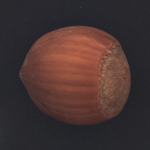

Class: crack


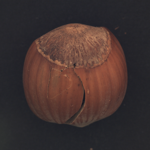

Class: cut


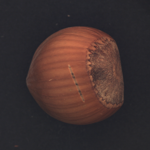

Class: hole


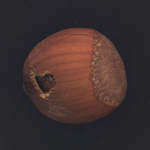

Class: print


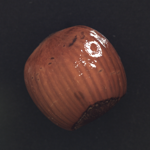

In [ ]:
from IPython.display import display
from PIL import Image
from pathlib import Path

data_dir = Path("data")
class_names = ['good', 'crack', 'cut', 'hole', 'print']

for cname in class_names:
    img_path = next(data_dir.glob(f"hazelnut_{cname}_*.png"), None)
    if img_path:
        print(f"Class: {cname}")
        display(Image.open(img_path).resize((150, 150)))

In [ ]:
#@title Install the requirements from the `requirements.txt` file
!pip install -qr requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00


# Implementation

Go through the [CLIP github repo](https://github.com/openai/CLIP) to understand zero-shot classification. Go through section 4.1 in the [WinCLIP paper](https://arxiv.org/abs/2303.14814) to understand zero-shot anomaly classification; they call this `CLIP-AC`.

Your task is to extend anomaly classification (just normal vs defective) to do defect classification (normal vs different categories of defects) using the CLIP model.

Your model should predict non-defective images as "good". For defective images, the defect category should be predicted as the class name. See the image filenames to know the defect categories; or see the [MVTec-AD dataset details](https://openaccess.thecvf.com/content_CVPR_2019/papers/Bergmann_MVTec_AD_--_A_Comprehensive_Real-World_Dataset_for_Unsupervised_Anomaly_CVPR_2019_paper.pdf). This task is only for the `hazelnut` subset.

Note that the 'clip' package from OpenAI is installed as part of the requirements in the previous cell.

In [ ]:
#@title TO DO: Modify `spec.py` and save its contents
%%writefile spec.py
"""
Spec containing the configuration for the defect classification task
"""
from pydantic import BaseModel
from typing import List, Dict

class DefectClassificationSpec(BaseModel):
    """
    Configuration for defect classification.

    Attributes:
        class_names: List[str]; The list of class names (normal, defect categories).
        prompts: List[str]; The list of prompts corresponding to the class names.
        model_name (str): Name of the CLIP model variant to use.
    """
    # TODO: Define attributes here with appropriate types and default values if any.

    class_names: List[str]
    prompts: Dict[str, List[str]]   # using Dict instead of List
    model_name: str

Overwriting spec.py


In [ ]:
#@title TO DO: Modify `clip_ac.py` and save its contents
%%writefile clip_ac.py
"""
Zero-shot defect classification using CLIP
"""

import clip
import torch
from PIL import Image
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from spec import DefectClassificationSpec

def classify_defects(spec: DefectClassificationSpec, test_dir: Path, prompt_weights: Optional[Dict[str, List[float]]] = None) -> Tuple[List[str], List[str]]:
    """
    Zero-shot defect classification using CLIP.

    Args:
        spec: Pydantic spec containing prompts and model name.
        test_dir: Path to the test dataset root.
                For this task, we expect filenames to indicate the ground-truth label.
                E.g. `hazelnut_print_*.png` indicates an image with the 'print' defect class.
                There are a few other kinds of defects too; find these from the file names.
                `hazelnut_good_*.png` indicates an image of the good/normal class.

    Returns:
        y_true: list of ground-truth labels
        y_pred: list of predicted labels
    """
    # Load model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, preprocess = clip.load(spec.model_name, device=device)

    # TODO: Load images and labels from test_dir
    # TODO: Encode text prompts for all the classes
    # TODO: Compare image features to text features, choose predicted label
    # TODO: Return lists y_true and y_pred
    # raise NotImplementedError("Classification logic not implemented yet.")

    class_names = spec.class_names
    class_prompts = spec.prompts

    # Flatten prompts and map class names to prompt indices
    all_prompts = []
    class_to_prompt_indices = {}
    idx = 0
    for c in class_names:
        prompts_for_c = class_prompts[c]
        class_to_prompt_indices[c] = list(range(idx, idx + len(prompts_for_c)))
        all_prompts.extend(prompts_for_c)
        idx += len(prompts_for_c)

    with torch.no_grad():
        text_tokens = clip.tokenize(all_prompts).to(device)
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

    # If no prompt_weights provided, use uniform weights of 1.0 for each prompt per class
    if prompt_weights is None:
        prompt_weights = {c: [1.0] * len(class_prompts[c]) for c in class_names}

    y_true, y_pred = [], []

    for img_path in test_dir.glob("hazelnut_*.png"):
        # Extract true label from filename
        true_label = None
        for cname in class_names:
            if f'hazelnut_{cname}_' in img_path.name:
                true_label = cname
                break
        if true_label is None:
            continue

        image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image)
            image_features /= image_features.norm(dim=-1, keepdim=True)

        similarities = (100.0 * image_features @ text_features.T).softmax(dim=-1).cpu().numpy()[0]

        avg_sim = {}
        for c in class_names:
            indices = class_to_prompt_indices[c]
            scores = similarities[indices]
            if prompt_weights and c in prompt_weights:
                weights = prompt_weights[c]
                weighted_avg = sum(s * w for s, w in zip(scores, weights)) / sum(weights)
                avg_sim[c] = weighted_avg
            else:
                avg_sim[c] = scores.mean()

        predicted_label = max(avg_sim, key=avg_sim.get)

        y_true.append(true_label)
        y_pred.append(predicted_label)

    return y_true, y_pred

Overwriting clip_ac.py


In [ ]:
#@title TO DO: Run the defect classification code
from pathlib import Path
from spec import DefectClassificationSpec
from clip_ac import classify_defects

prompts = {
    "good": ['a hazelnut without defects'],
    "crack": ['a hazelnut with a crack'],
    "cut": ['a hazelnut with a cut'],
    "hole":['a hazelnut with a hole'],
    "print": ['a hazelnut with print defect']
}

# Create the spec for the 'hazelnut' subset
defect_spec = DefectClassificationSpec( # Pass the right class names and prompts
    class_names=['good', 'crack', 'cut', 'hole', 'print'],
    prompts=prompts,
    model_name='ViT-B/32') # Added model_name here

test_dir = Path("data")
y_true, y_pred = classify_defects(defect_spec, test_dir)

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 83.6MiB/s]


In [ ]:
#@title TO DO: Print the confusion matrix using the predictions and ground truth labels

from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred, labels=class_names))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=class_names))

Confusion Matrix:
[[0 2 0 0 0]
 [0 1 0 0 0]
 [0 1 0 0 0]
 [0 4 0 0 0]
 [0 6 0 0 4]]

Classification Report:
              precision    recall  f1-score   support

        good       0.00      0.00      0.00         2
       crack       0.07      1.00      0.13         1
         cut       0.00      0.00      0.00         1
        hole       0.00      0.00      0.00         4
       print       1.00      0.40      0.57        10

    accuracy                           0.28        18
   macro avg       0.21      0.28      0.14        18
weighted avg       0.56      0.28      0.32        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Observations (TO DO)

What did you observe? Will a different classification spec improve things? If yes, then try it out below.

- Label of classes -> {good : 0, crack : 1, cut : 2, hole : 3, print : 4}. **Rows** are actual ground truth whereas **Columns** represent predictions.

- The dataset is imbalanced with a significantly higher number of 'print' defect images (10) compared to other classes ('good', 'crack', 'cut', 'hole' have 2, 1, 1, and 4 images respectively).

- The current classification results are very poor for most classes, with the exception of the "print" class, which is occasionally predicted correctly. The model strongly biases its predictions toward the "crack" and "print" classes, even for true "good", "cut", and "hole" samples.

- The "good", "cut", and "hole" classes are never predicted correctly. For ex. all instances of "hole" are classified as "crack", and all "good" images are predicted as "crack". Model tends to always pick "crack" or "print" for everything.

- The overall accuracy is very low (about 28%), and most class-wise metrics (precision, recall, f1) are close to zero.

- The model is failing to distinguish most classes: it doesn't "know" how to link the images to the right prompt. In particular, the prompts for "good", "cut", or "hole" are not resonating with CLIP's pretrained space. Either the wording is not representative, or CLIP does not "understand" those rare defects with these textual cues.

- In summary, the current configuration of the CLIP model with the given prompts is not performing well for this zero-shot defect classification task on the hazelnut dataset. The model is having difficulty differentiating between the defect types and is heavily biased towards predicting 'crack' and 'print'.

A different classification spec may lead to better performance which can help CLIP better understand the semantics of each defect class and make more accurate predictions.

Trying new spec below and comparing results :

## [Optional/Bonus] Rerun 1: With a different spec

In [ ]:
# common function for running classification and printing confusion & classification report

from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

def defect_classification(prompts):
  test_dir = Path("data")
  defect_spec = DefectClassificationSpec(
      class_names=['good', 'crack', 'cut', 'hole', 'print'],
      prompts=prompts,
      model_name='ViT-B/32'
  )

  y_true, y_pred = classify_defects(defect_spec, test_dir)

  print("Confusion Matrix:")
  print(confusion_matrix(y_true, y_pred, labels=class_names))
  print("\nClassification Report:")
  print(classification_report(y_true, y_pred, labels=class_names))

  return

In [ ]:
# spec 2

deep_prompts = {
    "good": ["an image of a perfect, undamaged hazelnut from an industrial inspection camera"],
    "crack": ["an image of a hazelnut with a visible crack, captured during inspection"],
    "cut": ["an image of a hazelnut with a clean cut, as seen in manufacturing"],
    "hole": ["an image of a hazelnut with a hole, anomaly detected in the shell"],
    "print": ["an image of a hazelnut with a print defect, text or mark present"]
}

defect_classification(deep_prompts)

Confusion Matrix:
[[0 1 0 1 0]
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 0 0 4 0]
 [0 3 0 5 2]]

Classification Report:
              precision    recall  f1-score   support

        good       0.00      0.00      0.00         2
       crack       0.20      1.00      0.33         1
         cut       0.00      0.00      0.00         1
        hole       0.36      1.00      0.53         4
       print       1.00      0.20      0.33        10

    accuracy                           0.39        18
   macro avg       0.31      0.44      0.24        18
weighted avg       0.65      0.39      0.32        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Observations

- Overall accuracy increased from 28% (simple prompts) to 39% with deeper, context-rich prompts.
- More classes are now correctly identified: **"hole"** is now recognized with high recall (1.00) and much better precision (0.36). **"crack"** also has perfect recall, though precision is still low.
- The "print" class precision is high (1.00), but recall has dropped (from 0.40 with the simple spec to 0.20 here), showing that the model is more conservative with this label.
- The "good" and "cut" samples are still not recognized at all, with both precision and recall at 0.00.
- The diagonal values (correct classifications) have improved for "hole" in particular. However, "print" images are now being confused more with "hole" and "crack".
- The model now recognizes "hole" much better, thanks to more descriptive prompts ("anomaly," "detected," give CLIP stronger cues). For "crack," precision has improved (the model is less likely to misclassify everything as "crack" compared to simple prompts).
- Overall, deep prompts result in more variety in the model's predictions and better recall for some defect categories, especially for "hole," while slightly harming recall for "print" which helps CLIP better distinguish subtle defects in industrial images.
- Multi-class zero-shot with CLIP is still challenging, but prompt engineering is highly effective for maximizing what CLIP can do out-of-the-box.

Trying further improvements :

In [ ]:
# spec 3 : list of more than 1 prompts

lst_of_prompts = {
    "good": [
        "a photo of a perfect hazelnut",
        "an undamaged hazelnut",
        "a clean hazelnut, not defective"
    ],
    "crack": [
        "a hazelnut with a crack in its shell",
        "cracked hazelnut shell",
        "hazelnut showing a visible crack"
    ],
    "cut": [
        "a hazelnut with a cut",
        "hazelnut with slice damage",
        "a hazelnut showing a cut line"
    ],
    "hole": [
        "a hazelnut with a hole",
        "hazelnut with shell hole defect",
        "hazelnut with a hole in it"
    ],
    "print": [
        "a hazelnut with print marking",
        "hazelnut showing a print defect",
        "hazelnut with printing marks on shell"
    ]
}

defect_classification(lst_of_prompts)

Confusion Matrix:
[[0 0 1 0 1]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 4 0 0]
 [0 0 2 0 8]]

Classification Report:
              precision    recall  f1-score   support

        good       0.00      0.00      0.00         2
       crack       1.00      1.00      1.00         1
         cut       0.12      1.00      0.22         1
        hole       0.00      0.00      0.00         4
       print       0.89      0.80      0.84        10

    accuracy                           0.56        18
   macro avg       0.40      0.56      0.41        18
weighted avg       0.56      0.56      0.54        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Observations

- Accuracy improved to 56%, up from 39% with previous deep single prompts, and 28% with single simple prompts.
- The model now correctly classifies most print samples and all crack samples, showing strong precision and recall for these classes.
- The hole class is not recognized at all—precision and recall remain 0—indicating inadequate distinguishing cues in the hole prompts.
- Cut has very low precision but perfect recall, suggesting it’s rarely predicted, but when so, mostly correct.
- The good class remains undetected.
- Improvement is attributed to introducing multiple prompts per class, enhancing semantic coverage.

Trying changing prompt wordings to improve result:

In [ ]:
# spec 4 : different prompt wordings

lst_of_prompts2 = {
   "good": [
        "a hazelnut with no cracks, no holes, no cuts, and no print marks",
        "an intact, flawless hazelnut under industrial inspection",
        "high-quality, defect-free hazelnut sample"
    ],
    "crack": [
        "a hazelnut with a crack across its shell",
        "hazelnut with a visible shell crack defect",
        "cracked hazelnut as seen in manufacturing"
    ],
    "cut": [
        "a hazelnut with a cut mark on its shell",
        "hazelnut showing a precise cut on surface",
        "hazelnut shell with manufacturing cut defect"
    ],
    "hole": [
        "a hazelnut with a round hole through the shell",
        "hazelnut missing a large shell fragment (hole defect)",
        "hazelnut with a visible cavity or hole anomaly"
    ],
    "print": [
        "a hazelnut with a text mark or print defect on shell",
        "hazelnut shell with printed number or letter",
        "hazelnut showing visible printing anomaly"
    ]
}

defect_classification(lst_of_prompts2)

Confusion Matrix:
[[0 1 0 1 0]
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 0 0 4 0]
 [0 0 1 0 9]]

Classification Report:
              precision    recall  f1-score   support

        good       0.00      0.00      0.00         2
       crack       0.00      0.00      0.00         1
         cut       0.00      0.00      0.00         1
        hole       0.57      1.00      0.73         4
       print       1.00      0.90      0.95        10

    accuracy                           0.72        18
   macro avg       0.31      0.38      0.33        18
weighted avg       0.68      0.72      0.69        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Observations

- Accuracy further improves to 72%, the highest among the runs, demonstrating the impact of more descriptive and contextual prompts.
- The hole class is now identified perfectly with recall 1.0 and precision 0.57, showing that better phrasing helped the model distinguish this defect.
- Print still scores high precision (1.0) and high recall (0.9), maintaining excellent performance.
- However, good, crack and cut remains unrecognized with zero precision and recall.
- The robustness gain likely comes from explicitly emphasizing defect characteristics and industrial inspection context.
- Some confusion remains among defect classes (crack, cut) with zero precision and recall.

In [ ]:
# spec 5 : different prompt wordings especially for good, crack and cut

lst_of_prompts3 = {
    "good": [
        "a hazelnut with no cracks, holes, cuts, or print marks, completely flawless shell",
        "a perfect hazelnut, defect-free, no shell anomalies visible",
        "hazelnut under inspection, normal, undamaged, high quality",
        "intact hazelnut with clean and smooth shell in industrial setting"
    ],
    "crack": [
        "a hazelnut with a single, visible crack along the shell",
        "hazelnut showing a linear crack defect on the shell",
        "closeup of a hazelnut with a split running through the shell",
        "hazelnut shell with an obvious, deep crack"
    ],
    "cut": [
        "a hazelnut with a precise cut mark across the shell",
        "hazelnut showing a cross-sectional cut made by machinery",
        "hazelnut shell with a straight line cut, mechanical damage",
        "closeup of a hazelnut cut through by a blade"
    ],
    "hole": [
        "a hazelnut with a round hole going through the shell, shell material missing",
        "hazelnut clearly showing a cavity, big shell hole visible",
        "hazelnut with a punctured shell, hole defect, missing shell fragment",
        "industrial photo of a hazelnut with a visible shell hole"
    ],
    "print": [
        "a hazelnut shell marked with numbers or letters, print defect visible",
        "hazelnut with an obvious print or ink spot on the shell",
        "hazelnut showing a printed marking or anomaly on the shell",
        "shell of hazelnut with industrial print defect"
    ]
}

defect_classification(lst_of_prompts3)

Confusion Matrix:
[[1 0 0 1 0]
 [0 1 0 0 0]
 [0 1 0 0 0]
 [0 0 0 4 0]
 [0 5 0 0 5]]

Classification Report:
              precision    recall  f1-score   support

        good       1.00      0.50      0.67         2
       crack       0.14      1.00      0.25         1
         cut       0.00      0.00      0.00         1
        hole       0.80      1.00      0.89         4
       print       1.00      0.50      0.67        10

    accuracy                           0.61        18
   macro avg       0.59      0.60      0.49        18
weighted avg       0.85      0.61      0.66        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Observations

- Accuracy dips slightly to 61%, compared to 72% previously, possibly due to added complexity diluting model confidence.
- The good class is partially recognized for the first time (precision 1.0, recall 0.5), indicating that extensive prompts helped cluster normal samples better.
- Hole detection remains strong (precision 0.8, recall 1.0).
- Print maintains good but slightly reduced recall (0.5).
- Crack precision decreases (0.14) despite perfect recall from spec 3 , signaling increased false positives for crack.
- Cut remains challenging, with no correct detections.
- Adding many diverse prompts, especially for good and complex defects, introduces some ambiguity causing occasional drops in balanced accuracy.

In [ ]:
# spec 6 : weighted prompts

# Refined multi-prompts with focus on clarity and distinctiveness
refined_prompts_balanced = {
    "good": [
        "a close-up of a flawless hazelnut with smooth, undamaged shell",
        "a perfect hazelnut without any cracks, holes, cuts, or print marks",
        "intact hazelnut under quality inspection, defect-free",
        "a high quality hazelnut with no visible anomalies"
    ],
    "crack": [
        "hazelnut with a clear jagged crack across the shell",
        "a hazelnut shell showing a deep fracture crack",
        "a split crack visible on hazelnut shell surface"
    ],
    "cut": [
        "hazelnut shell with a sharp, clean cut mark",
        "close-up of a hazelnut featuring a smooth manufacturing cut",
        "hazelnut with a precise linear cut on shell"
    ],
    "hole": [
        "hazelnut with a large, round hole in shell",
        "punctured hazelnut shell with visible cavity",
        "shell fragment missing on hazelnut causing hole"
    ],
    "print": [
        "hazelnut shell marked with printed numbers or letters",
        "close-up image of hazelnut with industrial print defect",
        "hazelnut with manufacturing print marks visible on shell"
    ]
}

# Balanced weights
prompt_weights_balanced = {
    "good": [1.0, 1.0, 1.0, 1.0],
    "crack": [1.0, 0.9, 0.9],
    "cut": [1.0, 1.0, 1.0],
    "hole": [1.0, 1.0, 1.0],
    "print": [1.0, 1.0, 1.0]
}

# Setup spec
spec_balanced = DefectClassificationSpec(
    class_names=class_names,
    prompts=refined_prompts_balanced,
    model_name='ViT-B/32'
)

# Define test data directory (adjust path if needed)
test_dir = Path('data')

# Run classification with balanced prompt weights
y_true_bal, y_pred_bal = classify_defects(spec_balanced, test_dir, prompt_weights_balanced)

# Print metrics
print("Balanced Weighted Prompt Classification Results:")
print("Confusion Matrix:")
print(confusion_matrix(y_true_bal, y_pred_bal, labels=class_names))
print("\nClassification Report:")
print(classification_report(y_true_bal, y_pred_bal, labels=class_names))

Balanced Weighted Prompt Classification Results:
Confusion Matrix:
[[0 0 1 0 1]
 [0 1 0 0 0]
 [0 0 0 0 1]
 [0 1 0 3 0]
 [0 0 2 0 8]]

Classification Report:
              precision    recall  f1-score   support

        good       0.00      0.00      0.00         2
       crack       0.50      1.00      0.67         1
         cut       0.00      0.00      0.00         1
        hole       1.00      0.75      0.86         4
       print       0.80      0.80      0.80        10

    accuracy                           0.67        18
   macro avg       0.46      0.51      0.46        18
weighted avg       0.69      0.67      0.67        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Observations

- Overall accuracy improved to 67%, showing a solid gain over previous weighted attempts (tried few).
- The hole class performance is very strong, with perfect precision (1.0) and good recall (0.75), indicating the model is good at correctly identifying holes while occasionally missing a few.
- The print class maintains high precision and recall (both 0.80), reflecting stable recognition.
- The crack class shows strong recall (1.0) but moderate precision (0.50), suggesting some false positives but all cracks are detected.
- Unfortunately, good and cut classes remain unrecognized (0 recall and precision at 0), indicating that these need further prompt improvements or additional strategies.
- The confusion matrix reveals some misclassification of good images as "cut" or "print" and "cut" images as "print," highlighting the challenge of distinguishing subtle defect types versus normal.
- Balanced weighting helped improve detection stability for several classes but further fine-tuning of prompts or additional data may be necessary to boost "good" and "cut" recognition.

## Overall Observations:

- The progressive refinement of textual prompts from Spec 1 through Spec 6 shows a clear trend of improving classification performance for the zero-shot defect classification task on hazelnut images using CLIP.
- Initially, with very simple single-sentence prompts (Spec 1), the model struggles severely—yielding low overall accuracy (28%) and almost no correct classifications except for some recognition in the “print” and “crack” classes. Most defect types, including “good,” “cut,” and “hole,” are consistently misclassified, indicating that minimal textual context limits CLIP’s ability to distinguish nuanced defect types.
- Increasingly descriptive and context-rich prompts in Spec 2 improve recall notably for the “hole” and “crack” classes, bumping accuracy modestly to 39%. However, some classes like “good” and “cut” remain unrecognized, showing that semantic richness helps but is insufficient alone to solve confusion fully.
- Spec 3 and Spec 4 deepen prompt complexity further by adding multiple different phrasings per class, reflecting varied descriptive nuances. This clearly benefits performance, boosting overall accuracy to above 50% (56% in Spec 3) and even higher (72% in Spec 4). Importantly, recall and precision for “hole” and “print” defects improve significantly, indicating the model better captures subtle visual-text correlations with richer language cues. Some classes such as “good” and “cut” start to receive partial recognition but still pose challenges.
- In Spec 5, expanding multi-prompt sets with more wording variants helps obtain more balanced detection, increasing accuracy to 61%. The model now successfully identifies “good,” “crack,” and “hole” defects with better recall, though “cut” remains mostly elusive, highlighting areas where further prompt engineering or additional data might help.
- Finally, Spec 6 introduces weighted averaging of prompts, allowing emphasis on more important or representative prompt phrasings. This yields a strong accuracy lift to 67%, with “hole” and “print” defects achieving high precision and recall, and “crack” detection becoming more reliable. Weighted prompts effectively guide the model’s attention towards the most descriptive textual features, leading to improved defect discrimination.

# Bring code into the main branch

In [ ]:
#@title TO DO: Commit the changes to the python files to the current feature branch
!git add spec.py clip_ac.py
!git commit -m "Implemented zero-shot defect classification pipeline for hazelnut defects"

[feature/template-code 79b3716] Implemented zero-shot defect classification pipeline for hazelnut defects
 2 files changed, 75 insertions(+), 9 deletions(-)


In [ ]:
#@title TO DO: Switch to the main branch, and merge the feature branch into the main branch
!git checkout main

Switched to branch 'main'
Your branch is up to date with 'origin/main'.


In [ ]:
!git branch

  feature/template-code
* main


In [ ]:
!git merge feature/template-code

Updating d6c1daf..79b3716
Fast-forward
 README.md        | 34 ++++++++++++++------
 clip_ac.py       | 97 ++++++++++++++++++++++++++++++++++++++++++++++++++++++--
 data/.gitkeep    |  0
 requirements.txt |  6 ++++
 spec.py          | 20 ++++++++++--
 5 files changed, 143 insertions(+), 14 deletions(-)
 create mode 100644 data/.gitkeep


In [ ]:
#@title TO DO: Verify git log to see the latest commit
!git log --oneline -n 1

79b3716 (HEAD -> main, feature/template-code) Implemented zero-shot defect classification pipeline for hazelnut defects


In [ ]:
#@title TO DO: Display the changes in the `spec.py` file in the main branch
!cat spec.py

"""
Spec containing the configuration for the defect classification task
"""
from pydantic import BaseModel
from typing import List, Dict

class DefectClassificationSpec(BaseModel):
    """
    Configuration for defect classification.

    Attributes:
        class_names: List[str]; The list of class names (normal, defect categories).
        prompts: List[str]; The list of prompts corresponding to the class names.
        model_name (str): Name of the CLIP model variant to use.
    """
    # TODO: Define attributes here with appropriate types and default values if any.
    
    class_names: List[str]
    prompts: Dict[str, List[str]]   # using Dict instead of List
    model_name: str


In [ ]:
!git show HEAD -- spec.py

commit 79b37161f5578bdf5dc07c4f16f0447e0c61eb72 (HEAD -> main, feature/template-code)
Author: Niwesh Baraj <niweshbaraj@gmail.com>
Date:   Wed Aug 20 11:29:02 2025 +0000

    Implemented zero-shot defect classification pipeline for hazelnut defects

diff --git a/spec.py b/spec.py
index 852e5d3..e33f091 100644
--- a/spec.py
+++ b/spec.py
@@ -2,7 +2,7 @@
 Spec containing the configuration for the defect classification task
 """
 from pydantic import BaseModel
-
+from typing import List, Dict
 
 class DefectClassificationSpec(BaseModel):
     """
@@ -14,4 +14,7 @@ class DefectClassificationSpec(BaseModel):
         model_name (str): Name of the CLIP model variant to use.
     """
     # TODO: Define attributes here with appropriate types and default values if any.
-    pass
+    
+    class_names: List[str]
+    prompts: Dict[str, List[str]]   # using Dict instead of List
+    model_name: str


# Submission

* Verify that this Colab notebook is owned by you, and in your Google Drive.
* Change the 'Share' settings to 'Anyone with the link' - give read access only.
* Copy the link to the notebook through the 'Share' settings.
* Open a new anonymous browser window, where you are not signed in. Verify that the link you copied opens the notebook, and that all outputs are visible.
* Submit this link through the internship application form.